# Motion Analysis Mid-term Assignment

## 1. Objective
In this assignment, you will work on **change detection** and **blob matching** tasks.

---

## 2. Methodology Sketch
Change detection is based on a loop where, at each time frame, you compare the current frame $I_t$ with a reference image or background $B$.

### A. Background Initialization
The background is usually initialized ($B_0$) by taking an average of the first few frames (assuming they are relatively empty/static).

### B. Change Detection
At each time $t$:
1. **Update background $B_t$**: This is optional. Initially, you may keep it constant ($B_t = B_0$).
2. **Compute change detection map $M_t$**: Compare $B_t$ with the current frame $I_t$.

### C. Compute Connected Components (Blobs)
- Each group of connected pixels marked as changes is labeled with a common ID.
- *Suggested Libraries:* Use `skimage.measure.label` or OpenCV's `cv2.connectedComponents`.

### D. Map Cleaning
- Remove small connected components (noise).
- Apply **morphological operations** (erosion, dilation, opening, closing) to make components smoother, more compact, or to bridge small gaps between components.

### E. Blob Matching
Connect components across temporal frames to track motion:
- Compute matches between blobs in $M_t$ and $M_{t+1}$.
- **Criteria for matching:**
    - Vicinity (e.g., Euclidean distance between centroids).
    - Similarity (e.g., average intensity/color, area, shape descriptors).

---

## 3. Implementation Details

### Thresholding
- Start with **heuristics-based thresholds** ($	au$) as discussed in class.
- Experiment with **Otsu's Method**: Evaluate if it can be applied to this specific context and provide feedback on its effectiveness.

### Matching Strategies
- Experiment with different strategies (Distance-based vs. Descriptor-based).

---

## 4. Project Structure
Your code must be **modular, clear, and clean**. Each step (Initialization, Detection, Cleaning, Matching) should be implemented in its own function.

---

## 5. Experimental Analysis
This is a critical part of the assignment.
1. **Provided Video:** Perform your initial analysis and tuning on the provided sample video.
2. **Custom Video:** Acquire a video of your choice. Think about the specific challenges (e.g., lighting changes, occlusion, fast motion) you want to address.
3. **Discussion:** The notebook must include markdown cells reporting, commenting, and analyzing the results.

---

## 6. Optional Extension
- Integrate matching results over larger time spans (multi-frame tracking/trajectories).



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import measure, morphology, io


def initialize_background(video_path="video", num_frames=10):
    video_path = Path(video_path)
    frame_paths = sorted(video_path.glob("*.jpg"))

    if len(frame_paths) < num_frames:
        raise ValueError(f"Expected at least {num_frames} frames in {video_path}, found {len(frame_paths)}")

    frames = []
    for frame_path in frame_paths[:num_frames]:
        frame = io.imread(str(frame_path))
        if frame is None:
            raise FileNotFoundError(f"Could not read frame: {frame_path}")
        if frame.ndim == 3:
            frame = frame.mean(axis=2)
        frames.append(frame.astype(np.float32))

    return np.mean(frames, axis=0)

def load_frames(video_path):
    video_path = Path(video_path)
    frame_paths = sorted(video_path.glob("*.jpg"))
    if not frame_paths:
        raise ValueError(f"No frames found in {video_path}")

    frames = []
    for frame_path in frame_paths:
        frame = io.imread(str(frame_path))
        if frame.ndim == 3:
            frame = frame.mean(axis=2)
        frames.append(frame.astype(np.float32))

    return frames, frame_paths

def update_background(background, new_frame, alpha=0.1):
    if background.shape != new_frame.shape:
        raise ValueError("Background and new frame must have the same shape")
    if alpha < 0 or alpha > 1:
        raise ValueError("Alpha must be between 0 and 1")
    return alpha * new_frame + (1 - alpha) * background

def update_backgroundv2(background, new_frame, previous_frame, alpha=0.1, threshold=0.1):
    if background.shape != new_frame.shape:
        raise ValueError("Background and new frame must have the same shape")
    if alpha < 0 or alpha > 1:
        raise ValueError("Alpha must be between 0 and 1")
    if threshold < 0 or threshold > 1:
        raise ValueError("Threshold must be between 0 and 1")
    if np.abs(new_frame - previous_frame).mean() > threshold:
        return background
    return alpha * new_frame + (1 - alpha) * background

def compute_change_map(frame, background, threshold):
    if frame.shape != background.shape:
        raise ValueError("Frame and background must have the same shape")
    if threshold < 0:
        raise ValueError("Threshold must be non-negative")

    frame = frame.astype(np.float32)
    background = background.astype(np.float32)
    difference = np.abs(frame - background)
    return (difference > threshold).astype(np.uint8) * 255

def compute_change_maps_with_update_background(frames, initial_background, threshold, alpha=0.1):
    background = initial_background.astype(np.float32)
    change_maps = []

    for frame in frames:
        change_map = compute_change_map(frame, background, threshold)
        change_maps.append(change_map)
        background = update_background(background, frame, alpha=alpha)

    return change_maps

def compute_change_maps_with_update_backgroundv2(frames, initial_background, threshold, alpha=0.1, motion_threshold=0.1):
    background = initial_background.astype(np.float32)
    change_maps = []

    for index, frame in enumerate(frames):
        change_map = compute_change_map(frame, background, threshold)
        change_maps.append(change_map)

        previous_index = max(0, index - 3)
        previous_frame = frames[previous_index]
        background = update_backgroundv2(
            background,
            frame,
            previous_frame,
            alpha=alpha,
            threshold=motion_threshold,
        )

    return change_maps

def clean_map(m_t):
    passmask = morphology.disk(2)
    return morphology.binary_opening(m_t, passmask)

def compute_blobs(change_map):
    labeled_blobs = measure.label(change_map, connectivity=2)
    cleaned_blobs = morphology.remove_small_objects(labeled_blobs, min_size=20)
    return cleaned_blobs


def match_blobs(blobs_t, blobs_t_plus_1):
    pass

Frames loaded: 71
Change maps with update_background: 71
Change maps with update_backgroundv2: 71


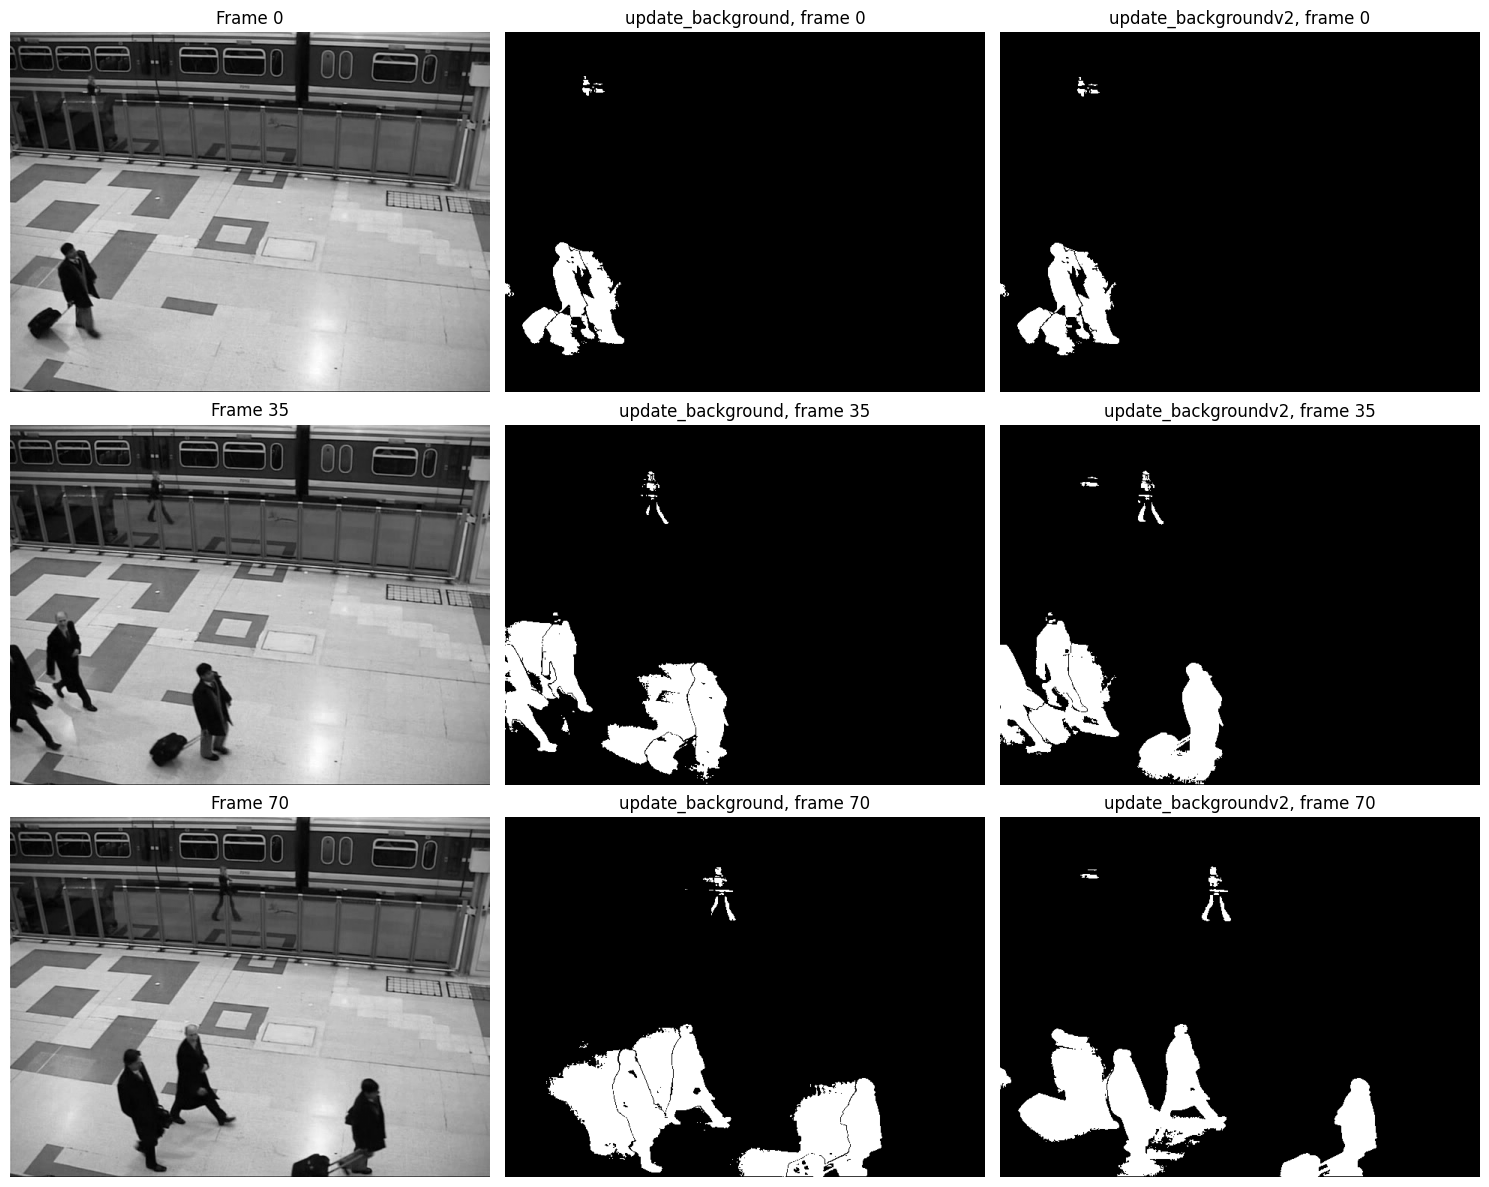

In [24]:
# Compute change maps for every station frame with two background update strategies
from pathlib import Path

video_dir = Path("video/station")
frames, frame_paths = load_frames(video_dir)
initial_background = initialize_background(video_path=video_dir, num_frames=10)

change_maps_update_background = compute_change_maps_with_update_background(
    frames,
    initial_background,
    threshold=30,
    alpha=0.1,
)

change_maps_update_backgroundv2 = compute_change_maps_with_update_backgroundv2(
    frames,
    initial_background,
    threshold=30,
    alpha=0.1,
    motion_threshold=0.2,
)

print(f"Frames loaded: {len(frames)}")
print(f"Change maps with update_background: {len(change_maps_update_background)}")
print(f"Change maps with update_backgroundv2: {len(change_maps_update_backgroundv2)}")

indices = [0, len(frames) // 2, len(frames) - 1]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for row, idx in enumerate(indices):
    axes[row, 0].imshow(frames[idx], cmap="gray")
    axes[row, 0].set_title(f"Frame {idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(change_maps_update_background[idx], cmap="gray", vmin=0, vmax=255)
    axes[row, 1].set_title(f"update_background, frame {idx}")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(change_maps_update_backgroundv2[idx], cmap="gray", vmin=0, vmax=255)
    axes[row, 2].set_title(f"update_backgroundv2, frame {idx}")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()